My conda environment looks like '~\anaconda3\envs\skmob\python.exe'

In [2]:
import networkx as nx
import pandas as pd # version 2.3.1 installed cocurrenlty with skmob
import geopandas as gpd #1.0.1
import numpy as np # 2.2.6
import shapely   # 2.0.7 , measure importance of features through SHAP values
import os
import skmob
import dropbox
import os
from dotenv import load_dotenv 
from dropbox import DropboxOAuth2FlowNoRedirect

Cannot find header.dxf (GDAL_DATA is not defined)


In [3]:
def authorize():
    load_dotenv()
    APP_KEY = os.environ.get("DROPBOX_APP_KEY")
    APP_SECRET = os.environ.get("DROPBOX_APP_SECRET")

    auth_flow = DropboxOAuth2FlowNoRedirect(APP_KEY,
                                            use_pkce = True,
                                            consumer_secret=APP_SECRET,
                                            token_access_type='offline',
                                            scope=['files.content.read'])

    authorize_url = auth_flow.start()
    print("1. Go to: " + authorize_url)
    print("2. Click \"Allow\" (you might have to log in first).")
    print("3. Copy the authorization code.")
    auth_code = input("Enter the authorization code here: ").strip()

    try:
        oauth_result = auth_flow.finish(auth_code)
        assert oauth_result.scope == 'files.content.read files.metadata.read'
    except Exception as e:
        print('Error: %s' % (e,))
        print(oauth_result.scope)
        exit(1)

    with dropbox.Dropbox(oauth2_access_token=oauth_result.access_token,
                        oauth2_access_token_expiration=oauth_result.expires_at,
                        oauth2_refresh_token=oauth_result.refresh_token,
                        app_key=APP_KEY,
                        app_secret=APP_SECRET) as dbx:        
        print("Successfully set up client!")
        return dbx

In [4]:
dbx = authorize()

1. Go to: https://www.dropbox.com/oauth2/authorize?response_type=code&client_id=vbt4c90yghbwqpt&token_access_type=offline&code_challenge=sYAvvhCOtQVlQU7_QQSv_soVbyHky236mCSLfZU76ak&code_challenge_method=S256&scope=files.content.read
2. Click "Allow" (you might have to log in first).
3. Copy the authorization code.
Successfully set up client!


In [6]:
from io import BytesIO

In [7]:
def load_data(dbx: dropbox.Dropbox, data_folder_path:str) -> dict: # tuple:
    """
    Returns:
        A tuple containing:
        - A dictionary with keys being each state code and values being the original datasets for that state with columns
        "Otract", "Dtract", "EST"
        - Ditto, but the dataset contains the columns "Id", "Jobs", "Pop" 
    """
    datasets = {}
    data_folder = dbx.files_list_folder(data_folder_path)
    for file in data_folder.entries:
        # file.name.split("_") creates list of items split from the filename -> [-1] access last item -> .split(".") splits last item by "."-> [0] accesses the first item which is the state code
        state_code = file.name.split("_")[-1].split(".")[0]
        file_path = data_folder_path + "/" + file.name
        meta_data, data = dbx.files_download(file_path)
        df = pd.read_csv(BytesIO(data.content))
        df['Otract'] = df['Otract'].astype(str)
        df['Dtract'] = df['Dtract'].astype(str)
        # Add the DataFrame to the container with the state code as the label
        datasets[state_code] = df
    dbx.close()
    assert not datasets['FL'].isna().values.any()
    return datasets 

In [8]:
# 1 min
datasets = load_data(dbx, "/Mobility Prediction/data/ctpp/2017-2021")

In [7]:
datasets['FL'].head()

,Otract,Dtract,EST
0,12001000201,12001000201,405.0
1,12001000201,12001000202,40.0
2,12001000201,12001000301,20.0
3,12001000201,12001000400,225.0
4,12001000201,12001000500,35.0


In [8]:
jobs = datasets['FL'].groupby('Dtract')['EST'].sum()

In [9]:
jobs.head()

Dtract
10003002800    15.0
10003011600    24.0
10003011900    10.0
10003013505    10.0
10003014706    35.0
Name: EST, dtype: float64

In [10]:
jobs.index

Index(['10003002800', '10003011600', '10003011900', '10003013505',
       '10003014706', '10003015000', '10003016309', '10005050801',
       '10005051302', '10005051312',
       ...
       '9009184700', '9009352100', '9009361402', '9011696300', '9011714101',
       '9013881300', '9015800501', '9015900100', '9015904400', '9015907100'],
      dtype='object', name='Dtract', length=8253)

In [11]:
count = 0
for id in datasets['FL']['Dtract'].unique():
    if id not in jobs.index:
        count += 1
print(count)

0


In [12]:
grouped = pd.DataFrame(set(datasets['FL']['Otract'].unique()).union(set(datasets['FL']['Dtract'].unique())), 
                        columns = ["Id"])
for id in grouped["Id"]:
    if id not in jobs.index:
        print(id, '\n')

12099005943 

12083000806 

12071010107 



In [104]:
print(max(jobs.index), min(jobs.index))
print(max(grouped['Id']), min(grouped['Id']))

56033000400 1003010100
56033000400 1003010100


# Traditional gravity model

To run the gravity model, we need our tessellation geodataframe to have the same tract ids as the set of tracts in our flows data. Note that the tract ids for the Dtracts in the flows data contain fips state codes (leading digits) that are different than 12, which is the state code for Florida. This will not match with the tessellation data, so we need to clean our flows dataset.

In [ ]:
print(min(datasets['FL']['Otract'].unique()), max(datasets['FL']['Otract'].unique()))
print(len(str(min(datasets['FL']['Otract'].unique()))), len(str(max(datasets['FL']['Otract'].unique()))))

12001000201 12133970303
11 11


In [ ]:
print(min(datasets['FL']['Dtract'].unique()), max(datasets['FL']['Dtract'].unique()))
print(len(str(min(datasets['FL']['Dtract'].unique()))), len(str(max(datasets['FL']['Dtract'].unique()))))

1003010100 56033000400
10 11


In [13]:
Otracts = datasets['FL']['Otract'].unique()
Dtracts = datasets['FL']['Dtract'].unique()

In [ ]:
anamolies = 0
for id in Otracts:
    if not id.startswith('12'):
        anamolies += 1
print(anamolies)
anamolies = 0
for id in Otracts:
    if len(id) != 11:
        anamolies += 1
print(anamolies)

0
0


Using https://tigerweb.geo.census.gov/tigerweb/ and the 2020 census layer we can identify tracts that are not in Florida and their locations. Some dtracts identified were census tracts in Texas, North Carolina, and Kentucky. These values would mean that a commuter originates in Fl (all Otracts have Fl fips) and arrive in a destination tract in Texas, etc. Also, the dtracts with 10 digit geoid should be county subdivisions, however no features were found with the 2020 county subdivision query filters. So, we will view these as tracts formatted incorrectly.  

In [ ]:
anamolies = 0
print("Tracts not in Florida:", '\n')
for id in Dtracts:
    if not id.startswith('12'):
        if anamolies < 5:
            print(id, '\n')
        anamolies += 1
print("Total: ", count, '\n')
print("Tracts formatted incorrectly:", '\n')
anamolies = 0
digits = set()
for id in Dtracts:
    if len(id) != 11:
        digits.add(len(id))
        if anamolies < 5:
            print(id, '\n')
        anamolies += 1
print("Total: ", anamolies)


Tracts not in Florida: 

1073002402 

48163950301 

37063002038 

21111003501 

21111011007 

Total:  3155 

Tracts formatted incorrectly: 

1073002402 

4013614700 

9001110202 

6059052439 

1101005904 

Total:  434


In [ ]:
for digit in digits:
    print(digit)

10


Clean the dataset to filter out tracts with a fips code other than their state code. Also, ignore tract data that is different than 11 digits.

In [9]:
fips_data = pd.read_csv("../data/2020_fips.txt", sep = "|")

In [ ]:
# type(fips_data)
fips_data.head()

,STATE,STATEFP,STATENS,STATE_NAME
0,AL,1,1779775,Alabama
1,AK,2,1785533,Alaska
2,AZ,4,1779777,Arizona
3,AR,5,68085,Arkansas
4,CA,6,1779778,California


In [11]:
fips_data[fips_data['STATE'] == "FL"]['STATEFP'].values[0]

np.int64(12)

In [12]:
fips_data[fips_data['STATE'] == "FL"]['STATEFP'].index[0]

np.int64(9)

In [ ]:
datasets['FL']['Dtract'][0]

12001000201

In [10]:
def clean_data(datasets: dict):
    for state_code, df in datasets.items():
        fips = str(fips_data[fips_data['STATE'] == state_code]['STATEFP'].values[0])
        df = df[df['Dtract'].str.startswith(fips)]
        df = df[df['Dtract'].str.len() == 11]
        datasets[state_code] = df
    return datasets
    

In [11]:
datasets_cleaned = clean_data(datasets)

In [ ]:
def get_grouped_data(datasets: dict):
    dsets_grouped = {}
    for state_code, df in datasets.items():
        grouped = pd.DataFrame(set(df['Otract'].unique()).union(set(df['Dtract'].unique())), 
                        columns = ["Id"])
        jobs = df.groupby('Dtract')['EST'].sum()
        grouped['Jobs'] = grouped['Id'].map(jobs)
        # store 'Jobs' as float since we will standardize values 
        grouped['Jobs'] = grouped['Jobs'].fillna(0).astype(float) 
        pop = df.groupby('Otract')['EST'].sum()
        grouped['Pop'] = grouped['Id'].map(pop)
        grouped['Pop'] = grouped['Pop'].fillna(0).astype(float)
        dsets_grouped[state_code] = grouped
    assert not dsets_grouped['FL'].isna().values.any()
    return dsets_grouped

In [13]:
data_grouped_cleaned = get_grouped_data(datasets_cleaned)

In [19]:
from skmob.utils import utils, constants
from skmob.models import gravity    

In [27]:
url_tess = skmob.utils.constants.NY_COUNTIES_2011
tessellation = gpd.read_file(url_tess).rename(columns={'tile_id': 'tile_ID'})

In [ ]:
tessellation.head()

,tile_ID,population,geometry
0,36019,81716,"POLYGON ((-74.00667 44.88602, -74.02739 44.995..."
1,36101,99145,"POLYGON ((-77.09975 42.27421, -77.09966 42.272..."
2,36107,50872,"POLYGON ((-76.25015 42.29668, -76.24914 42.302..."
3,36059,1346176,"POLYGON ((-73.70766 40.72783, -73.70027 40.739..."
4,36011,79693,"POLYGON ((-76.27907 42.78587, -76.27535 42.780..."


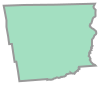

In [ ]:
tessellation['geometry'][0]

Tessellation is a geodataframe containing geometry represented as a GeoSeries.

In [ ]:
type(tessellation)

geopandas.geodataframe.GeoDataFrame

In [ ]:
type(tessellation['geometry'][0])

shapely.geometry.polygon.Polygon

In [ ]:
print(tessellation['geometry'][0].wkt, '\n')
print(tessellation['geometry'][0].boundary, '\n') # represents exterior of the shape, takes same values as wkt
print(tessellation['geometry'][0].area, '\n')
print(tessellation.crs)

POLYGON ((-74.006668 44.886017, -74.027389 44.995685, -73.87459699999999 45.001223, -73.639718 45.003464, -73.343124 45.01084, -73.35463300000001 44.987352, -73.350218 44.976222, -73.338244 44.964751, -73.339603 44.943371, -73.33897899999999 44.917681, -73.341106 44.914632, -73.350652 44.909634, -73.356218 44.904492, -73.360328 44.897236, -73.36910399999999 44.866681, -73.371968 44.862415, -73.379822 44.857038, -73.37954499999999 44.851651, -73.38159 44.849354, -73.380321 44.847173, -73.381336 44.844683, -73.379447 44.843461, -73.379452 44.83801, -73.37534599999999 44.836307, -73.368275 44.828007, -73.353472 44.820386, -73.335044 44.804109, -73.33315399999999 44.788759, -73.335713 44.782086, -73.34708500000001 44.77298, -73.354361 44.755296, -73.365562 44.741786, -73.365977 44.697559, -73.36130799999999 44.694524, -73.365297 44.687548, -73.370142 44.684855, -73.367209 44.678514, -73.371843 44.676957, -73.37101 44.672763, -73.372719 44.668739, -73.369668 44.663478, -73.374577 44.66189, 

In [1]:
tessellation.crs

NameError: name 'tessellation' is not defined

'Jobs' represents the inflows of a census tract (number of workers commuting to the tract for work). 'Pop' represents the outflows of a census tract (number of workers residing in the tract that leave to work in a different tract).

We need a spatial tesselation and a FlowDataFrame to generate the gravity model. The spatial tessellation structure can be found by navigating to <venv_path>/lib/Python3.9/site-packages/skmob/utils/constants

In [ ]:
# Upgrade geopandas from the version installed along skmob  
# %pip install --upgrade geopandas fiona

In [14]:
# are coordinates in decimal degrees?
fl_tessellation = gpd.read_file("../data/FL_2021_TRACT.gdb", layer = 'ACS_2021_5YR_TRACT_12_FLORIDA')

c:\Users\dylan\anaconda3\envs\skmob\lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files.  Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


In [ ]:
data_grouped_cleaned['FL'].head()

,Id,Jobs,Pop
0,12059960100,224.0,785.0
1,12099007767,735.0,1304.0
2,12031002102,607.0,1181.0
3,12115002727,498.0,379.0
4,12009060302,490.0,858.0


In [41]:
fl_tessellation.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [55]:
# fl_tessellation.head()
fl_tessellation.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'NAME', 'NAMELSAD', 'MTFCC',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'Shape_Length',
       'Shape_Area', 'GEOID_Data', 'geometry'],
      dtype='object')

Join fl_tesselation with dsets_grouped_cleaned['Fl'] based on the tract Id column

In [15]:
fl_tessellation.rename(columns = {'GEOID': 'Id'}, inplace = True)

In [24]:
fl_tessellation.head()

,STATEFP,COUNTYFP,TRACTCE,Id,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Length,Shape_Area,GEOID_Data,geometry
0,12,127,080600,12127080600,806,Census Tract 806,G5020,S,3855836.0,1396648.0,+29.2785973,-081.0550229,0.114930,0.000488,14000US12127080600,"MULTIPOLYGON (((-81.07344 29.29253, -81.07342 ..."
1,12,127,082406,12127082406,824.06,Census Tract 824.06,G5020,S,2161378.0,0.0,+29.1526295,-081.0085288,0.062435,0.000200,14000US12127082406,"MULTIPOLYGON (((-81.01981 29.15447, -81.01973 ..."
2,12,127,081300,12127081300,813,Census Tract 813,G5020,S,1352627.0,1263614.0,+29.2131309,-081.0042522,0.063099,0.000243,14000US12127081300,"MULTIPOLYGON (((-81.01538 29.21656, -81.0151 2..."
3,12,127,081500,12127081500,815,Census Tract 815,G5020,S,1159201.0,279283.0,+29.2239763,-081.0256998,0.055922,0.000133,14000US12127081500,"MULTIPOLYGON (((-81.03353 29.22556, -81.03318 ..."
4,12,127,081600,12127081600,816,Census Tract 816,G5020,S,1535085.0,0.0,+29.2220958,-081.0403122,0.049670,0.000142,14000US12127081600,"MULTIPOLYGON (((-81.0493 29.22347, -81.04926 2..."


In [ ]:
print(type(fl_tessellation['Id']))

<class 'pandas.core.series.Series'> <class 'str'>


Check to make sure the datatypes of the geoid columns match for validation purposes

In [37]:
print(type(fl_tessellation['Id'][0]), type(datasets_cleaned['FL']['Otract'][0]), type(dsets_grouped_cleaned['FL']['Id'][0]))

<class 'str'> <class 'str'> <class 'str'>


In [ ]:
# COMPLETE THE SAME CHECK FOR EVERY STATE
count = 0
for id in data_grouped_cleaned['FL']['Id']:
    if id not in fl_tessellation['Id'].values:
        count += 1
assert(count == 0)

In [ ]:
print(len(data_grouped_cleaned['FL']), len(fl_tessellation))

5101 5160


In [ ]:
fl_tessellation[fl_tessellation['Id'] == '12127081500'].index[0]

array([3])

In [16]:
indices = []
for id in fl_tessellation['Id']:
    if id not in data_grouped_cleaned['FL']['Id'].values:
        index = fl_tessellation[fl_tessellation['Id'] == id].index[0]
        indices.append(index)
fl_tessellation.drop(index = indices, inplace = True)

In [17]:
assert(len(data_grouped_cleaned['FL']) == len(fl_tessellation))

In [ ]:
flows_ex = skmob.utils.constants.NY_FLOWS_2011 #https://raw.githubusercontent.com/scikit-mobility/scikit-mobility/master/examples/NY_commuting_flows_2011.csv
flows_ex = pd.read_csv(flows_ex)

In [ ]:
flows_ex.head()

,flow,origin,destination
0,121606,36001,36001
1,5,36001,36005
2,29,36001,36007
3,11,36001,36017
4,30,36001,36019


In [40]:
datasets['FL'].head(2)

,Otract,Dtract,EST
0,12001000201,12001000201,405.0
1,12001000201,12001000202,40.0


In [29]:
fl_tessellation.head(1)

,STATEFP,COUNTYFP,TRACTCE,Id,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Length,Shape_Area,GEOID_Data,geometry
0,12,127,080600,12127080600,806,Census Tract 806,G5020,S,3855836.0,1396648.0,+29.2785973,-081.0550229,0.11493,0.000488,14000US12127080600,"MULTIPOLYGON (((-81.07344 29.29253, -81.07342 ..."


In [ ]:
data_grouped_cleaned['FL'].head(2)

,Id,Jobs,Pop
0,12011110357,752.0,3784.0
1,12057013003,1191.0,1669.0


In [ ]:
fl_tessellation = fl_tessellation.merge(data_grouped_cleaned['FL'], on='Id')

In [ ]:
fl_tessellation.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'Id', 'NAME', 'NAMELSAD', 'MTFCC',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'Shape_Length',
       'Shape_Area', 'GEOID_Data', 'geometry', 'Jobs', 'Pop'],
      dtype='object')

In [ ]:
fl_tessellation.head(1)

,STATEFP,COUNTYFP,TRACTCE,Id,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Length,Shape_Area,GEOID_Data,geometry,Jobs,Pop
0,12,127,080600,12127080600,806,Census Tract 806,G5020,S,3855836.0,1396648.0,+29.2785973,-081.0550229,0.11493,0.000488,14000US12127080600,"MULTIPOLYGON (((-81.073 29.293, -81.073 29.293...",2828.0,930.0


In [ ]:
names = set(fl_tessellation['NAME'])
len(names), len(fl_tessellation)
# names do not appear to be unique names, so drop them

(3709, 5101)

In [ ]:
ids = set(fl_tessellation['Id'])
# make sure every census tract has a unique id
assert(len(ids) == len(fl_tessellation))

In [ ]:
# keep statefp, countyfp as these can be used to identify areas for spatial cross validation
# Keeo intptlat, intptlon to use in distance calculation for basic gravity models
columns = ['NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT','ALAND', 'AWATER', 'Shape_Length', 'GEOID_Data']
fl_tessellation.drop(columns = columns, inplace = True)

In [ ]:
print(type(fl_tessellation['Jobs'][0]))

<class 'str'>


In [ ]:
# standardize the current predictors we will use: "shape_area", "jobs", "pop" so that large values don't dominate
# min-max works well for comparing distance over data points. https://www.geeksforgeeks.org/python/data-normalization-with-pandas/
columns = ['Shape_Area', 'Jobs', 'Pop']
for col in columns:
    fl_tessellation[col] = ( (fl_tessellation[col] - fl_tessellation[col].min()) /  
    (fl_tessellation[col].max() - fl_tessellation[col].min()) )

Add socio-economic variables

In [ ]:
fl_commuting = gpd.read_file("../data/FL_2021_TRACT.gdb", layer = 'X08_COMMUTING')
fl_poverty = gpd.read_file("../data/FL_2021_TRACT.gdb", layer = 'X17_POVERTY')
fl_income = gpd.read_file("../data/FL_2021_TRACT.gdb", layer = 'X19_INCOME')

ArcGIS Pro accepts decimal degree notation with  '+' and '-' to indicate hempishere (N, S, E, W) and a leading zero as optional. The R package we will use does not accept this format however, so we will clean the coordinates to remove leading zeros and plus signs.

In [26]:
fl_tessellation["INTPTLON"][0], fl_tessellation["INTPTLAT"][0]

('-081.0550229', '+29.2785973')

In [27]:
import re

In [ ]:
fl_tess_cleaned = fl_tessellation.copy()

In [ ]:
# checks all values in "INTPTLON" and removes any '0' that follows the leading character
p = '^.0'
fl_tess_cleaned['INTPTLON'] = fl_tess_cleaned['INTPTLON'].apply(
    lambda x: re.sub(p, '', x) if re.match(p,x) else x
)

In [ ]:
p = '^.'
fl_tess_cleaned['INTPTLAT'] = fl_tess_cleaned['INTPTLAT'].apply(
    lambda x: re.sub(p, '', x) if re.match(p,x) else x
)

In [ ]:
fl_tess_cleaned["INTPTLON"].head(), fl_tess_cleaned["INTPTLAT"].head()

(0    81.0550229
 1    81.0085288
 2    81.0042522
 3    81.0256998
 4    81.0403122
 Name: INTPTLON, dtype: object,
 0    29.2785973
 1    29.1526295
 2    29.2131309
 3    29.2239763
 4    29.2220958
 Name: INTPTLAT, dtype: object)

In [ ]:
# verify same columns exist in both datasets
for col in fl_tessellation.columns:
    if col not in fl_tess_cleaned.columns:
        print(col)

TIGER REST API call to read in geodatabases from other states

In [ ]:
type(fl_tessellation), type(datasets_cleaned['FL'])

(geopandas.geodataframe.GeoDataFrame, pandas.core.frame.DataFrame)

In [ ]:
fl_tessellation.to_file("../data/fl_tess.shp") # store on local data folder
fl_tess_cleaned.to_file("../data/fl_tess_fixed.shp")
datasets_cleaned['FL'].to_csv("../data/fl_flows_cleaned.csv", index = False)

Apply to traditional model

In [ ]:
# check implementation of grouped datasets and that census tracts are same as in datasets origin, dest
# fdf = skmob.FlowDataFrame(datasets['FL'],
#                             origin = 'Otract',
#                             destination = 'Dtract',
#                             flow = 'EST',
#                             tile_id='Id',
#                             tessellation= fl_tessellation)

### Now add additional predictors to use:
- SVI info for each census tract
- POI_lon, POI_lat where POI is the some POI for each census tract
- POI_text which is textual data about the rating, review of the POI